<a href="https://colab.research.google.com/github/Nikhil0264/Collab_special/blob/main/Credit_Risk_analysis_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df['loan_status'].unique()

array([1, 0])

In [8]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

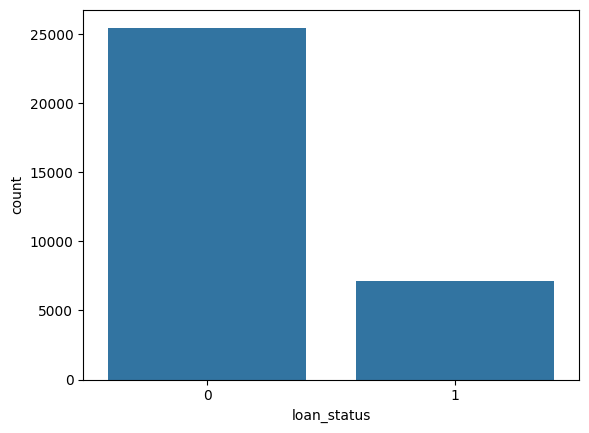

In [10]:
sns.countplot(x='loan_status',data=df)

In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [16]:
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

In [17]:
categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

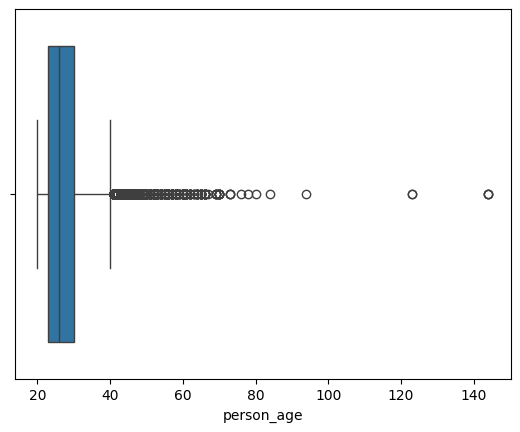

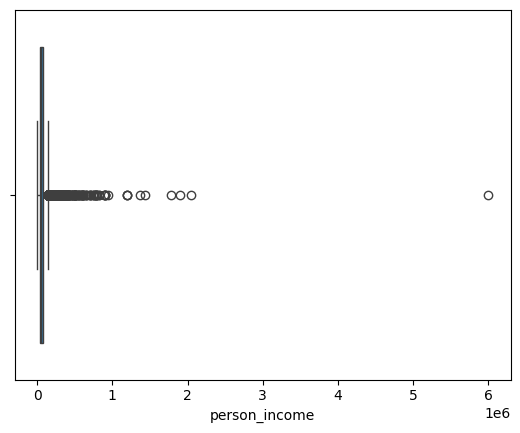

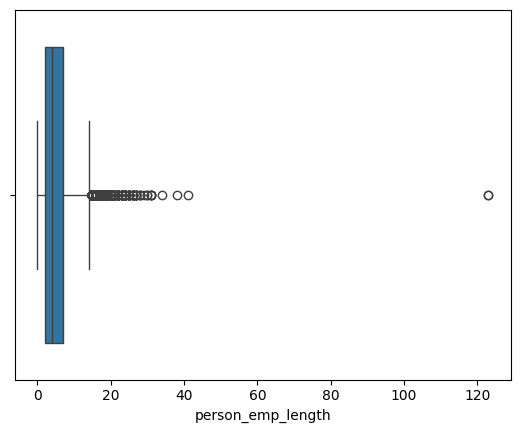

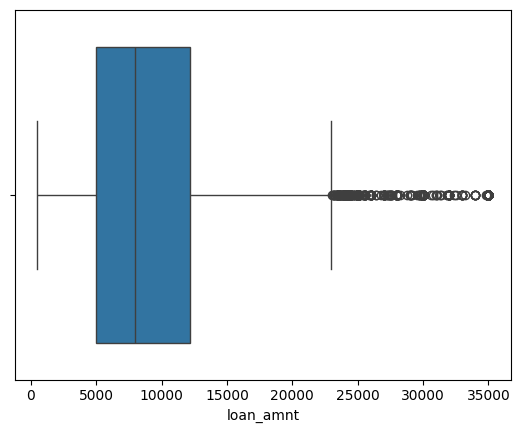

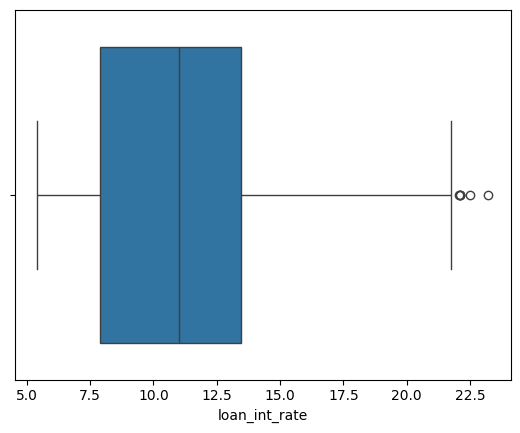

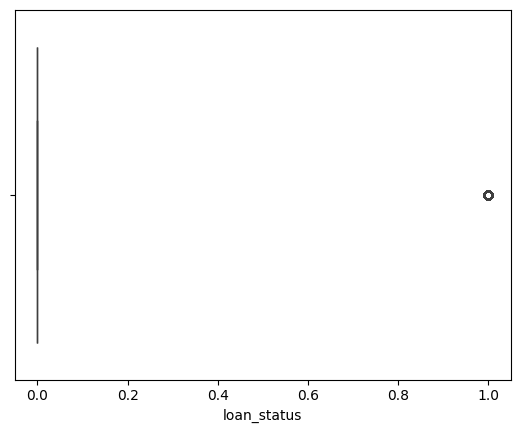

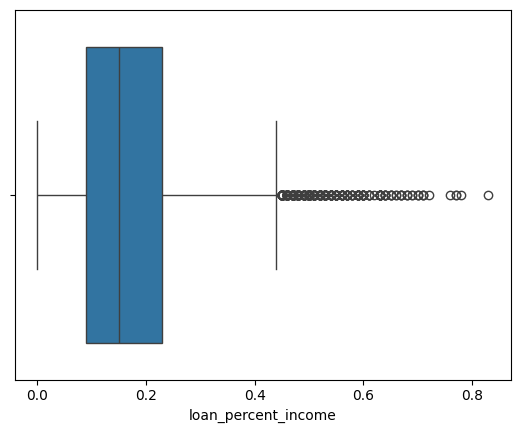

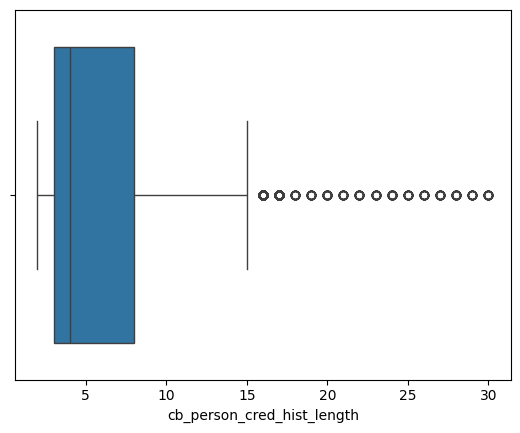

In [18]:
for i in numerical_cols:
  sns.boxplot(x=df[i],data=df)
  plt.show()

In [19]:
(df['person_age'] > 100).sum()

np.int64(5)

In [20]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

<Axes: >

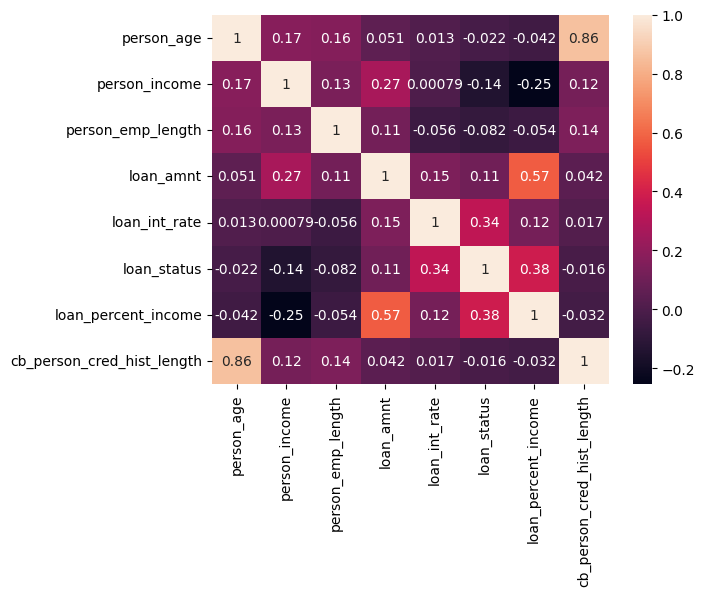

In [25]:
from __future__ import annotations
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [26]:
df_copy = df.copy()
print(f"Original Rows : {df_copy.shape[0]}")

df_copy.drop_duplicates(inplace=True)
print(f"After Removing Duplicates : {df_copy.shape[0]}")

Original Rows : 32581
After Removing Duplicates : 32416


In [27]:
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

In [28]:
df_copy = df_copy[df_copy['person_emp_length'] >= 0]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

In [29]:
df_copy = df_copy[df_copy['loan_int_rate'] >= 0]
df_copy = df_copy[df_copy['loan_int_rate'] <= 100]

In [30]:
df_copy = df_copy[df_copy['loan_amnt'] >= 0]

In [31]:
X = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [33]:
numeric_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
categorical_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

In [34]:
y_train.value_counts()

,count
loan_status,
0,17846
1,4950


In [35]:
neg,pos = np.bincount(y_train)
scale_weight = neg/pos

In [36]:
scale_weight

np.float64(3.605252525252525)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numeric_cols),
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [39]:
preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
        ]),numeric_cols),
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [72]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_recall_curve,classification_report,confusion_matrix,precision_score,recall_score,f1_score
def evaluate_model(model_name,model,x_test,y_test,threshold=None):

  print(f"Model : {model_name}")
  y_pred_proba = model.predict_proba(x_test)[:,1]
  if threshold is not None:
    y_pred = (y_pred_proba >= threshold).astype(int)
  else:
    y_pred = model.predict(x_test)

  accuracy_score1 = accuracy_score(y_test,y_pred)
  precision_score1 = precision_score(y_test,y_pred)
  recall_score1 = recall_score(y_test,y_pred)
  f1_score1 = f1_score(y_test,y_pred)
  roc_auc_score1 = roc_auc_score(y_test,y_pred_proba)

  cm = confusion_matrix(y_test,y_pred)
  class_report = classification_report(y_test,y_pred)
  sns.heatmap(cm,annot=True,fmt="d")
  plt.show()
  print(f"Accuracy : {accuracy_score1}")
  print(f"Precision : {precision_score1}")
  print(f"Recall : {recall_score1}")
  print(f"F1 : {f1_score1}")
  print(f"ROC AUC : {roc_auc_score1}")
  print()
  print(class_report)
  print()
  print("-"*50)
  precision,recall,threshold = precision_recall_curve(y_test,y_pred_proba)
  plt.plot(recall,precision)
  plt.title(f"Precision Recall Curve of {model_name}")
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.show()

In [46]:
from sklearn.model_selection import StratifiedKFold,cross_validate
from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring = {'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':"f1"}



In [42]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))
])


In [43]:
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [45]:
from xgboost import XGBClassifier

xg_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(n_estimator=300,max_depth=5,learning_rate=0.1,scale_pos_weight=scale_weight,random_state=42))
])
xg_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

In [51]:
for cv_name ,pipe in [('LogisticRegression',lr_cv_pipeline),('XGBoost',xg_cv_pipeline)]:
  cv_results = cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)

  print(cv_name)
  print(f"ROC AUC : {np.mean(cv_results['test_roc_auc'])}")
  print(f"Accuracy : {np.mean(cv_results['test_accuracy'])}")
  print(f"Precision : {np.mean(cv_results['test_precision'])}")
  print(f"Recall : {np.mean(cv_results['test_recall'])}")
  print(f"F1 : {np.mean(cv_results['test_f1'])}")
  print()

LogisticRegression
ROC AUC : 0.8723189618970608
Accuracy : 0.8125108614924017
Precision : 0.5482946003214749
Recall : 0.775959595959596
F1 : 0.6425345950302089

XGBoost
ROC AUC : 0.9386779397235119
Accuracy : 0.9054662552960598
Precision : 0.7827449631584541
Recall : 0.7824242424242425
F1 : 0.782315486438731



In [48]:
cv_results

{'fit_time': array([0.94317269, 0.9427104 , 0.53199005, 0.70708203, 0.6611383 ]),
 'score_time': array([0.08561158, 0.08338428, 0.14080667, 0.2404592 , 0.10398555]),
 'test_roc_auc': array([0.93762018, 0.940513  , 0.94089975, 0.93047695, 0.94387982]),
 'test_accuracy': array([0.89671053, 0.90940996, 0.90809388, 0.90282957, 0.91028734]),
 'test_precision': array([0.75516224, 0.80336488, 0.77268386, 0.78638743, 0.7961264 ]),
 'test_recall': array([0.77575758, 0.77171717, 0.81717172, 0.75858586, 0.78888889]),
 'test_f1': array([0.76532138, 0.78722308, 0.79430535, 0.7722365 , 0.79249112])}

In [56]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ("preprocessor",preprocessor_lr),
    ('Classifier',LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('Classifier', LogisticRegression(class_weight='balanced'))])

In [57]:
xg_model = Pipeline([
    ("preprocessor",preprocessor_xg),
    ('Classifier',XGBClassifier(learning_rate=0.1,scale_pos_weight=scale_weight,random_state=42))
])
xg_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Model : Baseline Logistic Regression Model


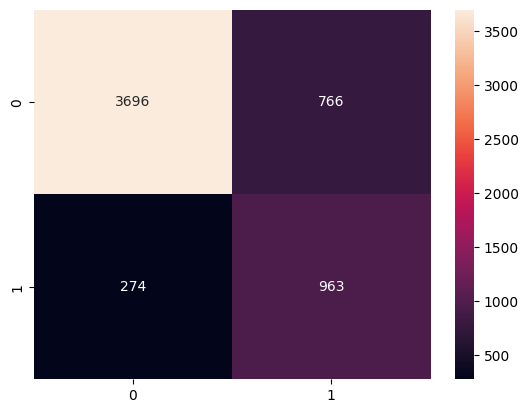

Accuracy : 0.81751184418319
Precision : 0.5569693464430306
Recall : 0.778496362166532
F1 : 0.6493594066082266
ROC AUC : 0.8729735008317792

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4462
           1       0.56      0.78      0.65      1237

    accuracy                           0.82      5699
   macro avg       0.74      0.80      0.76      5699
weighted avg       0.85      0.82      0.83      5699


--------------------------------------------------


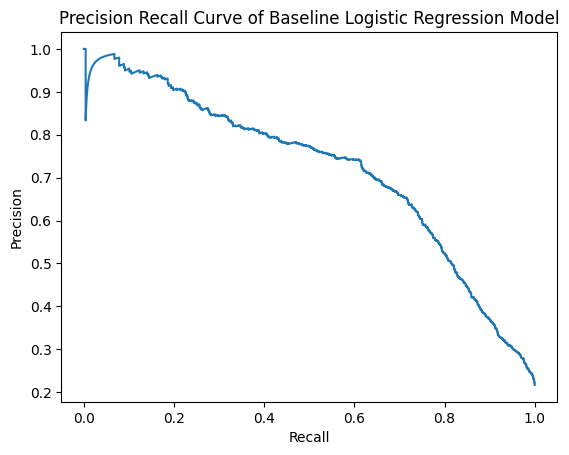

In [64]:
evaluate_model("Baseline Logistic Regression Model",baseline_model,X_test,y_test)

Model : XGBoost Model


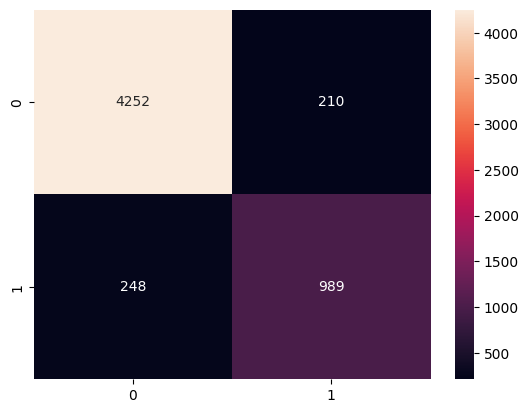

Accuracy : 0.9196350236883664
Precision : 0.8248540450375312
Recall : 0.799514955537591
F1 : 0.8119868637110016
ROC AUC : 0.9476500019748186

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4462
           1       0.82      0.80      0.81      1237

    accuracy                           0.92      5699
   macro avg       0.88      0.88      0.88      5699
weighted avg       0.92      0.92      0.92      5699


--------------------------------------------------


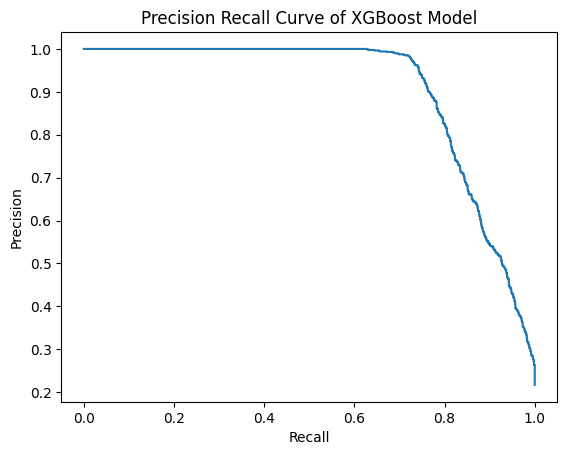

In [65]:
evaluate_model("XGBoost Model",xg_model,X_test,y_test)

In [67]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    "Classifier__n_estimators": np.arange(150, 801),
    "Classifier__max_depth": np.arange(3, 10),
    "Classifier__learning_rate": np.linspace(0.01, 0.5, 100),
    "Classifier__subsample": np.linspace(0.4, 0.6, 50),
    "Classifier__colsample_bytree": np.linspace(0.4, 0.6, 50),
    "Classifier__gamma": np.arange(0, 5),
    "Classifier__min_child_weight": np.arange(1, 10)
}

In [68]:
random_search = RandomizedSearchCV(
   xg_model,
    param_distributions=param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
   verbose=1,
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
       0.48163265, 0.48571429, 0.48979592, 0.49387755, 0.49795918,
       0.50204082, 0.50612245, 0.51020408, 0.51428571, 0.51836735,
       0.52244898, 0.52653061, 0.53061224, 0.53469388, 0.53877551,
       0.54285714, 0.54693878, 0.55102041, 0.55510204, 0.55918367,
       0.56326531, 0.56734694, 0.57142857, 0.5755102 , 0.57959184,
       0.58367347, 0.5877551 , 0.59183673, 0.59591837, 0.6       ])},
                   scoring='average_precision', verbose=1)

In [69]:
random_search.best_params_

{'Classifier__subsample': np.float64(0.5469387755102041),
 'Classifier__n_estimators': np.int64(676),
 'Classifier__min_child_weight': np.int64(2),
 'Classifier__max_depth': np.int64(9),
 'Classifier__learning_rate': np.float64(0.03474747474747475),
 'Classifier__gamma': np.int64(0),
 'Classifier__colsample_bytree': np.float64(0.4571428571428572)}

In [70]:
random_search.best_score_

np.float64(0.8977587188053041)

Model : XGBoost Model


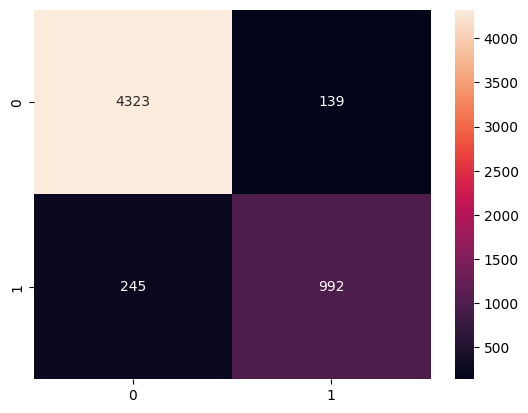

Accuracy : 0.9326197578522548
Precision : 0.8770999115826702
Recall : 0.8019401778496362
F1 : 0.8378378378378378
ROC AUC : 0.9525663040851209

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4462
           1       0.88      0.80      0.84      1237

    accuracy                           0.93      5699
   macro avg       0.91      0.89      0.90      5699
weighted avg       0.93      0.93      0.93      5699


--------------------------------------------------


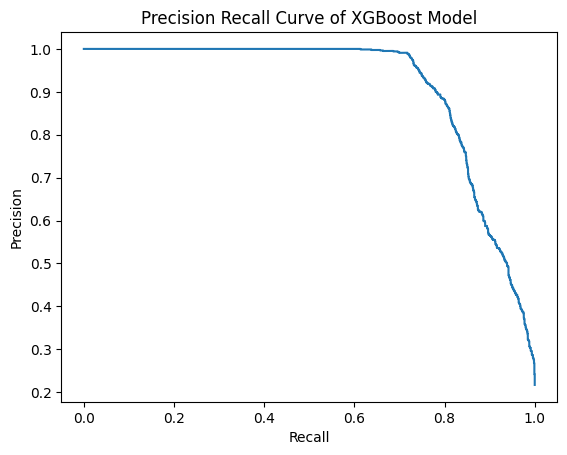

In [71]:
evaluate_model("XGBoost Model",random_search,X_test,y_test)

Best Precision : 0.9602094240837696
Best Threshold : 0.7132958769798279
Model : XGBoost Model


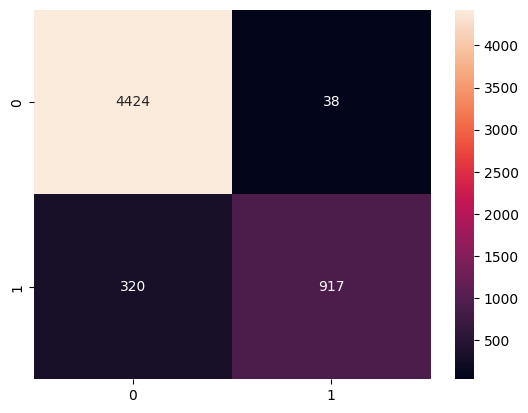

Accuracy : 0.937181961747675
Precision : 0.9602094240837696
Recall : 0.7413096200485044
F1 : 0.8366788321167883
ROC AUC : 0.9476500019748186

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4462
           1       0.96      0.74      0.84      1237

    accuracy                           0.94      5699
   macro avg       0.95      0.87      0.90      5699
weighted avg       0.94      0.94      0.93      5699


--------------------------------------------------


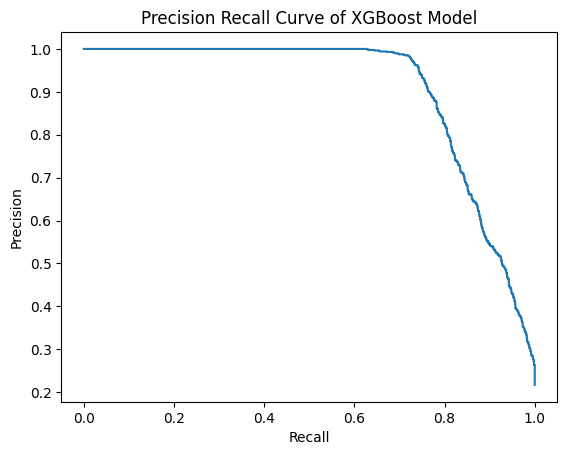

In [74]:
prob = xg_model.predict_proba(X_test)[:,1]
precisions,recalls,thresholds = precision_recall_curve(y_test,prob)

f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
ix = np.argmax(f1)
print(f"Best Precision : {precisions[ix]}")
print(f"Best Threshold : {thresholds[ix]}")
best_threshold = thresholds[ix]

evaluate_model("XGBoost Model",xg_model,X_test,y_test,best_threshold)

In [109]:
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(best_model,method="sigmoid",cv=cv)
calibrated_model.fit(X_train,y_train)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_le...
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.03474747474747475),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=np.int64(9),
                                                                max_leaves=None,
                                                                min_child_weight=np.int64(2),
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=np.int64(676),
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [110]:
uncalibrated_prob = xg_model.predict_proba(X_test)[:,1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:,1]

In [111]:
uncalibrated_prob

array([0.9481536 , 0.999131  , 0.00262947, ..., 0.33642623, 0.00673261,
       0.98613167], dtype=float32)

In [112]:
calibrated_prob

array([0.94326175, 0.95753346, 0.02348076, ..., 0.06551584, 0.0235061 ,
       0.95488818])

In [113]:
actual_uncal,predicted_uncal,thresholds_uncal = precision_recall_curve(y_test,uncalibrated_prob)
actual_cal,predicted_cal,thresholds_cal = precision_recall_curve(y_test,calibrated_prob)

Text(0, 0.5, 'Precision')

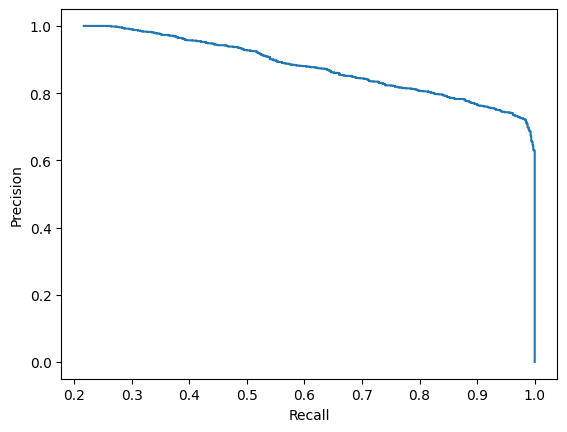

In [114]:
plt.plot(actual_uncal,predicted_uncal,label="Uncalibrated")
plt.xlabel("Recall")
plt.ylabel("Precision")

Text(0, 0.5, 'Precision')

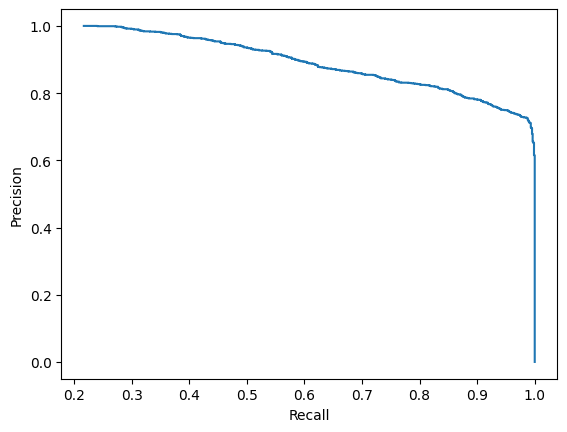

In [115]:
plt.plot(actual_cal,predicted_cal,label="calibrated")
plt.xlabel("Recall")
plt.ylabel("Precision")

In [116]:
import shap

In [117]:
xgb_classifier = xg_model.named_steps["Classifier"]
xgb_classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [118]:
X_text_transformed = xg_model.named_steps["preprocessor"].transform(X_test)

In [119]:
features_names = xg_model.named_steps["preprocessor"].get_feature_names_out()

In [120]:
x_test_df = pd.DataFrame(X_text_transformed,columns=features_names)

In [121]:
x_test_df.head()

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,23.0,46000.0,2.0,12800.0,19.41,0.28,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,24.0,16800.0,2.0,6000.0,14.84,0.36,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,24.0,120000.0,0.0,5775.0,6.17,0.05,2.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,22.0,41838.0,0.0,6600.0,16.89,0.16,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,33.0,44000.0,2.0,7000.0,12.99,0.16,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [122]:
explainer = shap.TreeExplainer(xgb_classifier)

In [123]:
shap_values = explainer.shap_values(x_test_df)

In [124]:
shap_values

array([[-2.6925212e-02,  7.7566855e-02,  6.1792088e-01, ...,
        -1.6014222e-02,  2.0966459e-02,  0.0000000e+00],
       [-5.7308050e-03,  2.1929374e+00,  1.4287999e-01, ...,
        -5.0164661e-03,  1.8678354e-02,  0.0000000e+00],
       [-1.6371162e-01, -6.6610157e-01,  5.8257181e-02, ...,
        -6.7259539e-03, -8.1922062e-02,  0.0000000e+00],
       ...,
       [-9.6412554e-02,  2.9908152e-02,  2.6903713e-02, ...,
        -9.2660943e-03, -3.4720190e-03,  0.0000000e+00],
       [ 2.4721058e-02, -7.3015809e-01, -6.5253921e-02, ...,
        -9.0470295e-03, -6.7865796e-02,  0.0000000e+00],
       [ 9.2826419e-02,  3.9281125e+00, -4.9119936e-03, ...,
        -6.1866655e-03, -9.1374537e-04,  0.0000000e+00]], dtype=float32)

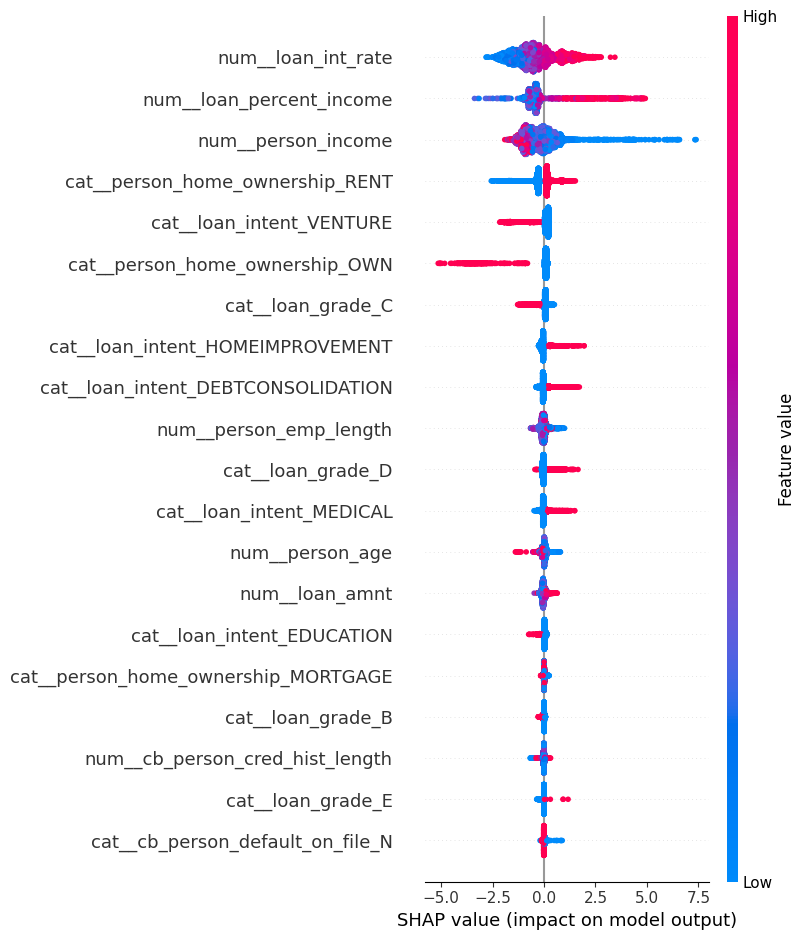

In [125]:
shap.summary_plot(shap_values,x_test_df)

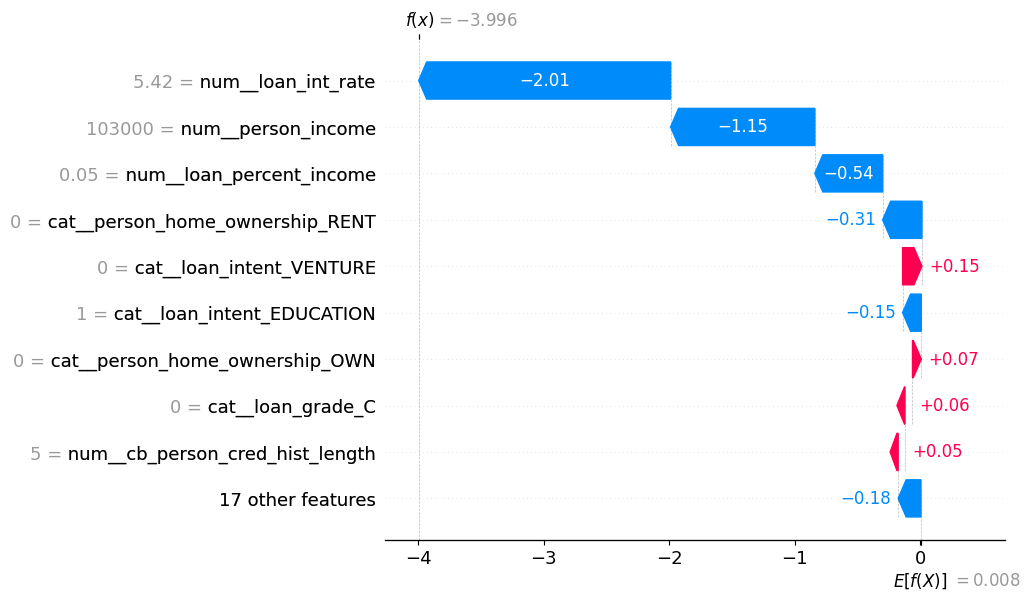

In [126]:
row_index = 9

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = x_test_df.iloc[row_index],
        feature_names = features_names
    )
)

In [127]:
y_pred = random_search.predict(X_test)

In [128]:
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [129]:
result_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
13588,23,46000,RENT,2.0,EDUCATION,F,12800,19.41,0.28,Y,3,1,1
6107,24,16800,RENT,2.0,DEBTCONSOLIDATION,D,6000,14.84,0.36,Y,4,1,1
6052,24,120000,RENT,0.0,VENTURE,A,5775,6.17,0.05,N,2,0,0
7402,22,41838,RENT,0.0,MEDICAL,D,6600,16.89,0.16,N,3,1,1
21698,33,44000,MORTGAGE,2.0,EDUCATION,C,7000,12.99,0.16,Y,8,1,0


In [130]:
false_positives = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

In [131]:
false_positives.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
23107,28,54000,RENT,5.0,DEBTCONSOLIDATION,C,8000,15.23,0.15,N,9,0,1
21543,28,31000,RENT,3.0,PERSONAL,D,6000,15.33,0.19,N,9,0,1
11325,25,73163,MORTGAGE,9.0,VENTURE,E,25000,16.45,0.34,N,3,0,1
27217,27,59200,RENT,4.0,DEBTCONSOLIDATION,B,15000,10.75,0.25,N,7,0,1
30262,39,60000,RENT,2.0,DEBTCONSOLIDATION,C,6000,15.27,0.10,N,14,0,1


In [132]:
false_negtive = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [133]:
false_negtive.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
21698,33,44000,MORTGAGE,2.0,EDUCATION,C,7000,12.99,0.16,Y,8,1,0
27976,32,31000,RENT,0.0,EDUCATION,B,5000,11.49,0.16,N,8,1,0
26715,27,44000,RENT,2.0,MEDICAL,B,2000,11.49,0.05,N,10,1,0
17630,25,63600,MORTGAGE,9.0,DEBTCONSOLIDATION,B,7000,11.49,0.11,N,4,1,0
23704,32,59000,MORTGAGE,0.0,MEDICAL,C,3500,13.72,0.06,N,6,1,0


In [134]:
print(len(false_positives))
print(len(false_negtive))

139
245


In [135]:
import joblib
joblib.dump(calibrated_model,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [136]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']